# Mini-Project 1: UBOS District Population Forecaster

**What the planning unit asked.** Give us five-year population forecasts so
we can budget primary-school classrooms. How many extra classrooms does each
district need by 2029?

**The data.** Population estimates in **thousands**, 2015-2024. Kampala,
Wakiso and Gulu are the figures supplied in the brief and are *illustrative*,
not official UBOS releases. **Masaka** and **Lira** are the two additional
districts required by task 1. Both are regional service centres rather than
dormitory suburbs of Kampala, so they act as a counterweight to the central
growth belt instead of repeating it.

**Where the code lives.** `src/population.py` holds the domain classes.
`src/forecasting.py` holds the abstract `Forecaster`, assembled out of the
three mixins in `src/mixins.py`, and `src/metrics.py` holds the error
measures. This notebook only runs the analysis and interprets it.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import statistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.charts import SERIES_COLOURS, store, use_house_style
from src.forecasting import EnsembleForecaster, Forecaster
from src.metrics import MetricSuite
from src.mixins import grid_search
from src.population import (
    PLANNING_HORIZON, TRAIN_UNTIL, CompoundGrowth, DistrictPopulation,
    GoldenRatioProjection, PolyfitTrend, SchoolCapacityModel, ValidationBench,
    fibonacci, load_series, projection, residual_bootstrap, spread_check)

use_house_style()
SEED = 1234
rng = np.random.default_rng(SEED)
pd.set_option("display.float_format", "{:,.3f}".format)

series = load_series()
print("loaded:", ", ".join(s.district for s in series))

loaded: Kampala, Wakiso, Gulu, Masaka, Lira


## Task 1: the `DistrictPopulation` class

The class stores years and populations as NumPy arrays and refuses input it
could not sensibly analyse. Beyond the `__repr__` and `__len__` the brief
asks for, it behaves like a read-only mapping: `series[2020]` looks a year
up, iterating yields `(year, population)` pairs, and `in` tests coverage.
That means the rest of the analysis can treat a district as data rather than
reaching into its attributes.

In [2]:
for s in series:
    print(repr(s))

kampala = series[0]
print("\nkampala[2020] =", kampala[2020])
print("first three pairs:", list(kampala)[:3])
print("2018 covered:", 2018 in kampala, "| 2035 covered:", 2035 in kampala)

<DistrictPopulation Kampala: 2015-2024, 10 points, last 1,800k>
<DistrictPopulation Wakiso: 2015-2024, 10 points, last 1,670k>
<DistrictPopulation Gulu: 2015-2024, 10 points, last 480k>
<DistrictPopulation Masaka: 2015-2024, 10 points, last 375k>
<DistrictPopulation Lira: 2015-2024, 10 points, last 580k>

kampala[2020] = 1500.0
first three pairs: [(2015, 1200.0), (2016, 1250.0), (2017, 1300.0)]
2018 covered: True | 2035 covered: False


Validation matters because each rejection below would otherwise surface much
later as a confidently wrong forecast.

In [3]:
rejections = {
    "lengths differ": dict(years=[2020, 2021], thousands=[1, 2, 3]),
    "negative population": dict(years=[2020, 2021], thousands=[100, -5]),
    "empty series": dict(years=[], thousands=[]),
    "years out of order": dict(years=[2021, 2020], thousands=[100, 110]),
    "non-finite value": dict(years=[2020, 2021], thousands=[100, np.inf]),
}
for description, kwargs in rejections.items():
    try:
        DistrictPopulation("Invalid", **kwargs)
    except ValueError as error:
        print(f"{description:<22} -> {error}")

lengths differ         -> years (2) and thousands (3) differ in length
negative population    -> population cannot be negative
empty series           -> thousands needs at least 1 value(s), got 0
years out of order     -> years must be strictly increasing
non-finite value       -> thousands must be finite (no NaN or inf)


## Task 2: the same statistics from two libraries

`statistics.variance` and `np.var` disagree because they estimate different
things.

* `statistics.variance` is the **sample** variance and divides by `n - 1`.
* `np.var` divides by `n - ddof`, and `ddof` defaults to **0**, so it returns
  the **population** variance unless told otherwise.

`ddof` is the "delta degrees of freedom" subtracted from `n` in the
denominator. One degree of freedom has already been spent estimating the
mean, so `ddof=1` removes it and makes the estimator unbiased when the ten
observations are treated as a *sample* from a process rather than as the
entire population of interest. With n = 10 the NumPy default therefore
reports a variance 10% smaller.

In [4]:
rows = []
for s in series:
    stdlib, pop_var, sample_var = s.summary_stdlib(), s.summary_numpy(0), s.summary_numpy(1)
    rows.append({
        "district": s.district,
        "mean": stdlib["mean"],
        "median": stdlib["median"],
        "var (statistics)": stdlib["variance"],
        "var (np, ddof=0)": pop_var["variance"],
        "var (np, ddof=1)": sample_var["variance"],
        "sd (statistics)": stdlib["stdev"],
    })
pd.DataFrame(rows).set_index("district")

,mean,median,var (statistics),"var (np, ddof=0)","var (np, ddof=1)",sd (statistics)
district,,,,,,
Kampala,"1,477.000","1,460.000","42,601.111","38,341.000","42,601.111",206.400
Wakiso,"1,280.000","1,260.000","60,066.667","54,060.000","60,066.667",245.085
Gulu,389.500,382.500,"2,885.833","2,597.250","2,885.833",53.720
Masaka,330.900,329.500,818.100,736.290,818.100,28.602
Lira,490.600,487.500,"3,290.711","2,961.640","3,290.711",57.365


In [5]:
n = len(kampala)
sample = kampala.summary_stdlib()["variance"]
population = kampala.summary_numpy(ddof=0)["variance"]
assert np.isclose(population, sample * (n - 1) / n)
assert np.isclose(sample, kampala.summary_numpy(ddof=1)["variance"])
print(f"sample variance     (/ n-1) : {sample:>12,.2f}")
print(f"population variance (/ n)   : {population:>12,.2f}")
print(f"ratio                       : {population / sample:.4f}   (= 9/10)")

sample variance     (/ n-1) :    42,601.11
population variance (/ n)   :    38,341.00
ratio                       : 0.9000   (= 9/10)


## Task 3: year-on-year growth and the CAGR

Year-on-year growth says how fast a district grew in a particular year. The
CAGR collapses the whole decade into the single constant rate that would
have carried it from its 2015 value to its 2024 value.

In [6]:
changes = pd.DataFrame({s.district: np.round(100 * s.annual_changes(), 2) for s in series},
                       index=[f"{y}->{y + 1}" for y in range(2015, 2024)])
changes.loc["CAGR"] = [round(100 * s.cagr(), 2) for s in series]
changes

,Kampala,Wakiso,Gulu,Masaka,Lira
2015->2016,4.170,5.260,3.120,3.100,3.660
2016->2017,4.000,7.000,4.550,2.340,4.470
2017->2018,3.850,7.480,4.350,3.590,3.380
2018->2019,5.190,6.090,4.170,2.210,4.360
2019->2020,5.630,6.560,4.000,3.400,3.550
2020->2021,5.330,6.920,5.130,2.990,4.440
2021->2022,4.430,6.470,4.880,2.320,3.470
2022->2023,4.240,6.080,5.810,3.400,4.290
2023->2024,4.650,6.370,5.490,2.740,3.760
CAGR,4.610,6.470,4.610,2.900,3.930


In [7]:
rates = {s.district: s.cagr() for s in series}
for name in sorted(rates, key=rates.__getitem__, reverse=True):
    print(f"{name:<10} {rates[name]:>7.2%} a year")
print(f"\nfastest in relative terms: {max(rates, key=rates.__getitem__)}")
print(f"slowest in relative terms: {min(rates, key=rates.__getitem__)}")
print("\nRelative and absolute growth point to different districts: Kampala adds")
print("the most people (600k over the decade) but Wakiso compounds fastest, and")
print("it is the compounding that drives the classroom bill.")

Wakiso       6.47% a year
Kampala      4.61% a year
Gulu         4.61% a year
Lira         3.93% a year
Masaka       2.90% a year

fastest in relative terms: Wakiso
slowest in relative terms: Masaka

Relative and absolute growth point to different districts: Kampala adds
the most people (600k over the decade) but Wakiso compounds fastest, and
it is the compounding that drives the classroom bill.


## Task 4: three models, three assumptions

All three subclass the abstract `Forecaster`, which fills in `fit()` and
`predict(horizon)` once and leaves subclasses two hooks, `_estimate` and
`_extrapolate`. What makes this build distinctive is where the rest of the
behaviour comes from: `Forecaster` inherits it from three independent mixins
rather than implementing it.

| Mixin | What it contributes |
|---|---|
| `SeriesValidationMixin` | coercion and the rejection rules |
| `ScoringMixin` | `.score(actual)` returning a `MetricSuite` |
| `WalkForwardMixin` | rolling-origin backtesting and `grid_search` |

The payoff is that a class can take only what it needs. `DistrictPopulation`
inherits `SeriesValidationMixin` alone -- it gets the input rules without
having to pretend to be a forecasting model.

In [8]:
print("Forecaster MRO:")
for klass in Forecaster.__mro__:
    print("   ", klass.__name__)

print("\nDistrictPopulation takes only the validation mixin:")
print("   ", [k.__name__ for k in DistrictPopulation.__mro__])

Forecaster MRO:
    Forecaster
    SeriesValidationMixin
    ScoringMixin
    WalkForwardMixin
    ABC
    object

DistrictPopulation takes only the validation mixin:
    ['DistrictPopulation', 'SeriesValidationMixin', 'object']


In [9]:
demo = CompoundGrowth().fit(kampala.thousands, kampala.years.astype(float))
print(repr(demo), "| implied growth:", f"{demo.rate_:.2%}")
print("chained:", np.round(CompoundGrowth().fit(kampala.thousands).predict(3), 1))

sequence = fibonacci(16)
ratios = sequence[1:] / sequence[:-1]
print("\nFibonacci:", sequence.astype(int).tolist())
print("ratios   :", np.round(ratios, 4).tolist())
print(f"phi = {(1 + np.sqrt(5)) / 2:.6f}, i.e. {(np.sqrt(5) - 1) / 2:.1%} growth a year")

CompoundGrowth(fitted, n=10) | implied growth: 4.61%
chained: [1882.9 1969.7 2060.5]

Fibonacci: [1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987]
ratios   : [1.0, 2.0, 1.5, 1.6667, 1.6, 1.625, 1.6154, 1.619, 1.6176, 1.6182, 1.618, 1.6181, 1.618, 1.618, 1.618]
phi = 1.618034, i.e. 61.8% growth a year


This build starts the Fibonacci ratios at term 2, so the first forecast steps
use the ratios while they are still unsettled -- 1.5, 1.667, 1.6, 1.625 --
before they converge. It makes no material difference to the verdict, but it
shows the convergence happening inside the forecast rather than hiding it.

## Task 5: validate before forecasting

Models are trained on **2015-2021** and scored on the held-out
**2022-2024**. Three measures are reported together because any one of them
can flatter a model: MAE is in thousands of people, RMSE punishes large
misses, and MAPE is unit-free so districts of different sizes compare.

In [10]:
bench = ValidationBench(train_until=TRAIN_UNTIL)
print(bench)

train, test = kampala.partition(TRAIN_UNTIL)
print(f"\ntrain {train.years[0]}-{train.years[-1]} (n={len(train)})")
print(f"test  {test.years[0]}-{test.years[-1]} (n={len(test)})")

ValidationBench(train_until=2021, models=['compound-growth', 'golden-ratio', 'polyfit-trend'])

train 2015-2021 (n=7)
test  2022-2024 (n=3)


In [11]:
for s in series:
    print(f"\n=== {s.district} " + "=" * (46 - len(s.district)))
    print(bench.table(s).to_string())
    print(f"--> selected: {bench.winner(s)}")


=== Kampala =======================================
                      MAE      RMSE  MAPE_%
model                                      
compound-growth     9.619    10.385   0.551
polyfit-trend      37.619    38.975   2.165
golden-ratio    2,490.000 2,939.484 141.466
--> selected: compound-growth

=== Wakiso ========================================
                      MAE      RMSE  MAPE_%
model                                      
compound-growth     6.802     8.049   0.420
polyfit-trend      49.405    52.368   3.094
golden-ratio    2,133.333 2,525.018 131.717
--> selected: compound-growth

=== Gulu ==========================================
                    MAE    RMSE  MAPE_%
model                                  
compound-growth   9.437  10.869   2.025
polyfit-trend    18.571  20.287   4.009
golden-ratio    638.333 753.818 136.655
--> selected: compound-growth

=== Masaka ========================================
                    MAE    RMSE  MAPE_%
model             

In [12]:
overview = pd.DataFrame([
    {"district": s.district,
     **{name: suite.mape for name, suite in bench.scores(s).items()},
     "selected": bench.winner(s)}
    for s in series]).set_index("district")
overview.columns = [c if c == "selected" else f"MAPE% {c}" for c in overview.columns]
overview

,MAPE% polyfit-trend,MAPE% compound-growth,MAPE% golden-ratio,selected
district,,,,
Kampala,2.165,0.551,141.466,compound-growth
Wakiso,3.094,0.420,131.717,compound-growth
Gulu,4.009,2.025,136.655,compound-growth
Masaka,0.601,0.368,150.301,compound-growth
Lira,1.289,0.348,144.623,compound-growth


**Result.** Compound growth wins on all five districts, with MAPE between
0.35% and 2.03%. The straight line is consistently second (0.60-4.01%): it is
not ridiculous, but it cannot bend, so it falls further behind each year.
The golden-ratio model is wrong by 132-150%.

## Models add together

`Forecaster.__add__` returns an `EnsembleForecaster` that fits every member
and averages their forecasts. Averaging is worth trying whenever two models
err in opposite directions and there is no clear reason to trust one over the
other. Whether it actually helps here is an empirical question, so it is
worth answering rather than assuming.

In [13]:
combined = PolyfitTrend() + CompoundGrowth()
combined.fit(train.thousands, train.years.astype(float))
print(repr(combined), "| members:", len(combined))

contest = {"polyfit-trend": PolyfitTrend(), "compound-growth": CompoundGrowth()}
for model in contest.values():
    model.fit(train.thousands, train.years.astype(float))
comparison = {name: model.score(test.thousands).mape for name, model in contest.items()}
comparison["ensemble (average)"] = combined.score(test.thousands).mape
pd.Series(comparison, name="MAPE %").to_frame().round(3)

EnsembleForecaster('polyfit-trend + compound-growth', n_members=2) | members: 2


,MAPE %
polyfit-trend,2.165
compound-growth,0.551
ensemble (average),0.807


**The ensemble does not help here, and it is worth being clear why.**
Averaging pays off when members miss in opposite directions, so their errors
partly cancel. On this data both models under-forecast -- the straight line
badly, compound growth slightly -- so averaging simply drags the better model
towards the worse one. The ensemble lands at 0.81% MAPE, between its two
members rather than below either. The right conclusion is to keep the single
best model and to treat the `__add__` operator as a tool that earns its place
only when the errors are genuinely uncorrelated.

## Task 6: forecast 2025-2029, and compare the variances

The winning model is refitted on the **full** 2015-2024 series before the
final forecast, so nothing observed is thrown away.

In [14]:
chosen = {s.district: bench.refit_winner(s) for s in series}
paths = {s.district: projection(s, chosen[s.district], PLANNING_HORIZON) for s in series}
pd.DataFrame(paths).round(1)

,Kampala,Wakiso,Gulu,Masaka,Lira
2025,"1,882.900","1,778.000",502.100,385.900,602.800
2026,"1,969.700","1,893.000",525.300,397.000,626.500
2027,"2,060.500","2,015.500",549.500,408.500,651.100
2028,"2,155.400","2,145.900",574.800,420.400,676.700
2029,"2,254.800","2,284.700",601.300,432.600,703.300


In [15]:
pd.DataFrame([{"district": s.district, **spread_check(s, paths[s.district].to_numpy())}
              for s in series]).set_index("district")

,observed_variance,forecast_variance,ratio
district,,,
Kampala,"42,601.111","21,607.682",0.507
Wakiso,"60,066.667","40,131.362",0.668
Gulu,"2,885.833","1,536.546",0.532
Masaka,818.100,340.788,0.417
Lira,"3,290.711","1,577.731",0.479


**Reading the variance difference.** The forecast series is less variable
than the observed one everywhere (ratios of 0.42-0.67). That is a fact about
the estimator, not a prediction that the future will be calmer. The observed
series contains the trend *plus* a decade of year-to-year scatter; a fitted
compound-growth curve is a smooth deterministic path with the scatter removed
by construction. Quoting the forecast variance as a measure of uncertainty
would understate the risk considerably. Genuine uncertainty has to be rebuilt
separately, which the bootstrap below attempts.

## Task 7: observed, fitted and forecast

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved: p1_population_paths.png


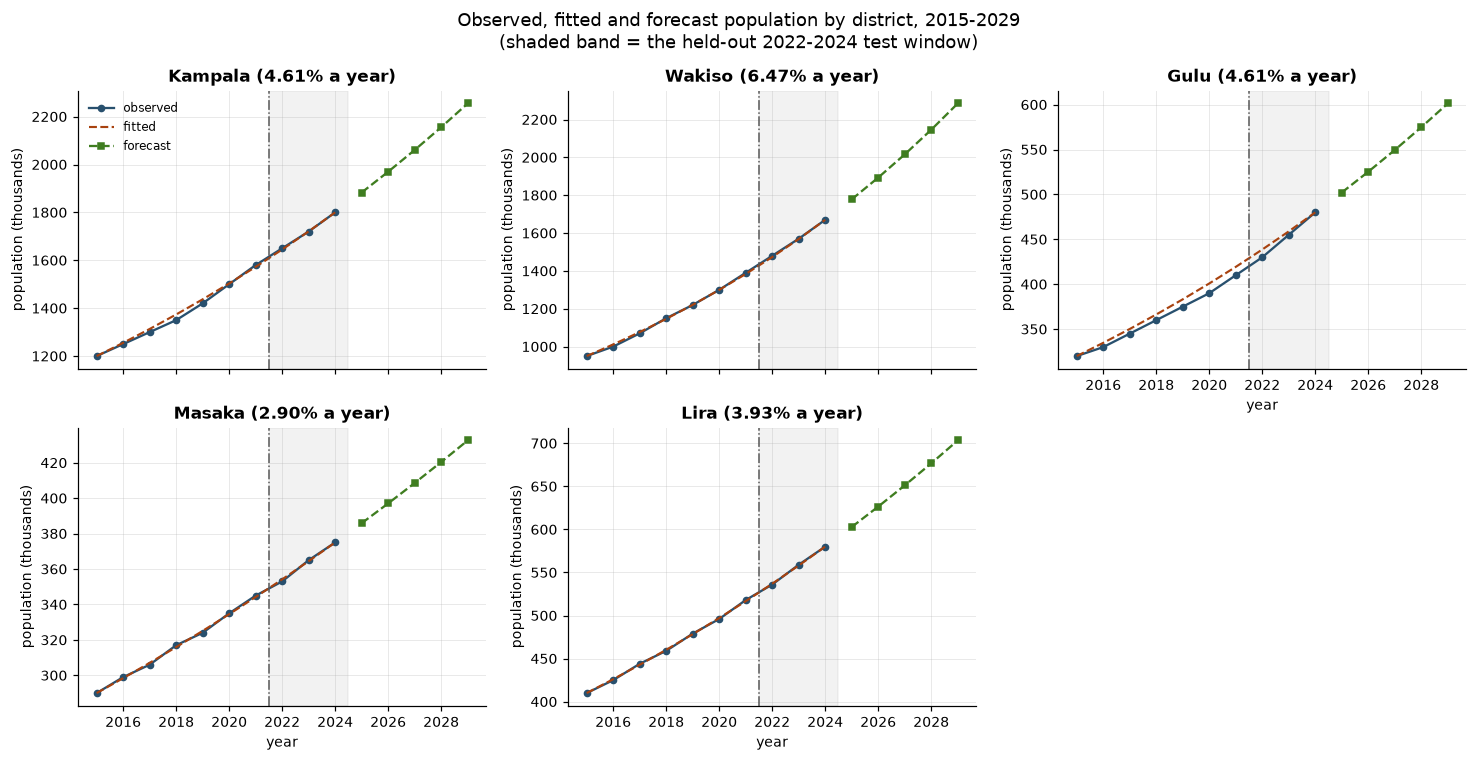

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7), sharex=True)
future = np.arange(2025, 2030)

for ax, s in zip(axes.flat, series):
    model, path = chosen[s.district], paths[s.district]
    ax.plot(s.years, s.thousands, "o-", color=SERIES_COLOURS[0], label="observed")
    ax.plot(s.years, model.fitted(), "--", color=SERIES_COLOURS[1], lw=1.4,
            label="fitted")
    ax.plot(future, path.to_numpy(), "s--", color=SERIES_COLOURS[2], label="forecast")
    ax.axvspan(2021.5, 2024.5, color="0.5", alpha=0.10)
    ax.axvline(2021.5, color="0.35", lw=1, ls="-.")
    ax.set_title(f"{s.district} ({s.cagr():.2%} a year)")
    ax.set_ylabel("population (thousands)")

axes.flat[-1].axis("off")
axes.flat[0].legend(loc="upper left", fontsize=8)
axes[0, 2].tick_params(labelbottom=True)
for ax in (axes[0, 2], *axes[1, :2]):
    ax.set_xlabel("year")
fig.suptitle("Observed, fitted and forecast population by district, 2015-2029\n"
             "(shaded band = the held-out 2022-2024 test window)", fontsize=12)
fig.tight_layout()
print("saved:", store(fig, "p1_population_paths.png").name)
plt.show()

## Task 8: classrooms needed by 2029

The brief's assumptions: 18% of the population is of primary-school age and a
classroom seats 53 pupils. `SchoolCapacityModel` is a frozen dataclass, so a
scenario cannot be edited mid-analysis -- a different assumption means a new,
named object.

In [17]:
planner = SchoolCapacityModel()
print(planner)

plan = pd.DataFrame([{
    "district": s.district,
    "2024 (k)": s.thousands[-1],
    "2029 (k)": round(float(paths[s.district].iloc[-1]), 1),
    "growth (k)": round(float(paths[s.district].iloc[-1]) - s.thousands[-1], 1),
    "new pupils": round(planner.enrolment(
        float(paths[s.district].iloc[-1]) - s.thousands[-1])),
    "extra classrooms": planner.rooms_to_add(
        s.thousands[-1], float(paths[s.district].iloc[-1])),
} for s in series]).set_index("district").sort_values("extra classrooms",
                                                      ascending=False)
plan

SchoolCapacityModel(primary_share=0.18, pupils_per_room=53)


,2024 (k),2029 (k),growth (k),new pupils,extra classrooms
district,,,,,
Wakiso,"1,670.000","2,284.700",614.700,110641,2088
Kampala,"1,800.000","2,254.800",454.800,81857,1545
Lira,580.000,703.300,123.300,22188,419
Gulu,480.000,601.300,121.300,21829,412
Masaka,375.000,432.600,57.600,10361,196


In [18]:
rate = kampala.cagr()
by_hand_2029 = kampala.thousands[-1] * (1 + rate) ** 5
by_hand_rooms = int(np.ceil((by_hand_2029 - kampala.thousands[-1]) * 1_000 * 0.18 / 53))
assert by_hand_rooms == plan.loc["Kampala", "extra classrooms"]
print(f"by hand: 1800 x {1 + rate:.5f}^5 = {by_hand_2029:,.1f}k")
print(f"         ({by_hand_2029:,.1f} - 1800) x 1000 x 0.18 / 53 = {by_hand_rooms:,}")
print(f"classes: {plan.loc['Kampala', 'extra classrooms']:,}   [match]")
print(f"\ntotal across the five districts: {plan['extra classrooms'].sum():,} classrooms")

by hand: 1800 x 1.04608^5 = 2,254.8k
         (2,254.8 - 1800) x 1000 x 0.18 / 53 = 1,545
classes: 1,545   [match]

total across the five districts: 4,660 classrooms


## Extension 1: prediction intervals from resampled residuals

A point forecast carries no uncertainty of its own. The residual bootstrap
reconstructs some: draw the model's training residuals with replacement
(2,000 resamples, above the 1,000 the brief requires), add them to the
forecast path, and read the 2.5th and 97.5th percentiles.

In [19]:
bands = {s.district: residual_bootstrap(chosen[s.district], PLANNING_HORIZON,
                                        draws=2000, coverage=0.95, seed=SEED)
         for s in series}

pd.DataFrame([{
    "district": s.district,
    "2029 point": round(float(bands[s.district]["point"].iloc[-1]), 1),
    "2029 lower": round(float(bands[s.district]["lower"].iloc[-1]), 1),
    "2029 upper": round(float(bands[s.district]["upper"].iloc[-1]), 1),
    "rooms (point)": planner.rooms_to_add(
        s.thousands[-1], float(bands[s.district]["point"].iloc[-1])),
    "rooms (upper)": planner.rooms_to_add(
        s.thousands[-1], float(bands[s.district]["upper"].iloc[-1])),
} for s in series]).set_index("district")

,2029 point,2029 lower,2029 upper,rooms (point),rooms (upper)
district,,,,,
Kampala,"2,254.800","2,231.100","2,262.300",1545,1571
Wakiso,"2,284.700","2,273.200","2,291.400",2088,2111
Gulu,601.300,590.400,601.300,412,412
Masaka,432.600,431.400,433.600,196,200
Lira,703.300,702.000,704.600,419,424


saved: p1_prediction_intervals.png


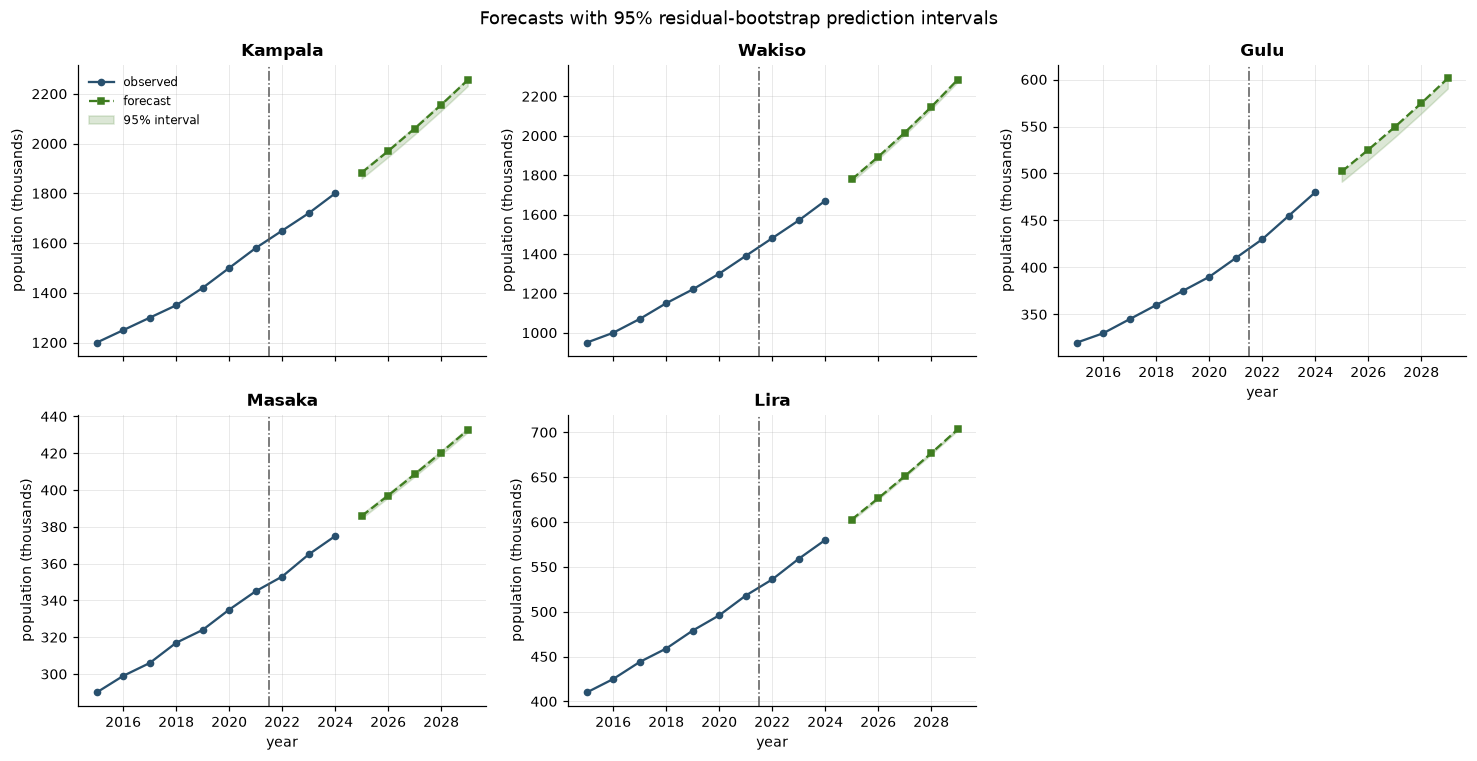

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7), sharex=True)
for ax, s in zip(axes.flat, series):
    band = bands[s.district]
    ax.plot(s.years, s.thousands, "o-", color=SERIES_COLOURS[0], label="observed")
    ax.plot(future, band["point"], "s--", color=SERIES_COLOURS[2], label="forecast")
    ax.fill_between(future, band["lower"], band["upper"], color=SERIES_COLOURS[2],
                    alpha=0.18, label="95% interval")
    ax.axvline(2021.5, color="0.35", lw=1, ls="-.")
    ax.set_title(s.district)
    ax.set_ylabel("population (thousands)")

axes.flat[-1].axis("off")
axes.flat[0].legend(loc="upper left", fontsize=8)
axes[0, 2].tick_params(labelbottom=True)
for ax in (axes[0, 2], *axes[1, :2]):
    ax.set_xlabel("year")
fig.suptitle("Forecasts with 95% residual-bootstrap prediction intervals", fontsize=12)
fig.tight_layout()
print("saved:", store(fig, "p1_prediction_intervals.png").name)
plt.show()

The bands are narrow: the upper bound adds only about 1% to the classroom
total. That is a statement about the **method**, not reassurance about the
future. A compound-growth curve is anchored on the first and last
observations, so it passes through both exactly and its training residuals
are small by construction. Resampling them measures how well the curve fits
points it was pinned to -- it cannot measure the risk that constant growth is
the wrong shape altogether, which is the larger danger over five years.

## Extension 2: is the Fibonacci-ratio model ever defensible?

Successive Fibonacci ratios converge on the golden ratio phi = 1.618..., so
after a few terms the model simply multiplies by 1.618 each year: a standing
assumption of **61.8% annual population growth**.

In [21]:
assessment = pd.DataFrame([{
    "district": s.district,
    "MAPE% golden-ratio": bench.scores(s)["golden-ratio"].mape,
    "MAPE% compound": bench.scores(s)["compound-growth"].mape,
    "actual CAGR %": 100 * s.cagr(),
} for s in series]).set_index("district")
assessment

,MAPE% golden-ratio,MAPE% compound,actual CAGR %
district,,,
Kampala,141.466,0.551,4.608
Wakiso,131.717,0.420,6.469
Gulu,136.655,2.025,4.608
Masaka,150.301,0.368,2.897
Lira,144.623,0.348,3.929


In [22]:
implied = (1 + np.sqrt(5)) / 2 - 1
fastest = max(rates.values())
print(f"growth implied by phi      : {implied:>7.1%} a year")
print(f"fastest district observed  : {fastest:>7.1%} a year")
print(f"overstatement              : {implied / fastest:>7.0f}x")
print(f"\ndoubling time at 61.8%     : {np.log(2) / np.log(1 + implied):>5.1f} years")
print(f"doubling time at Wakiso's  : {np.log(2) / np.log(1 + fastest):>5.1f} years")

growth implied by phi      :   61.8% a year
fastest district observed  :    6.5% a year
overstatement              :      10x

doubling time at 61.8%     :   1.4 years
doubling time at Wakiso's  :  11.1 years


**Assessment.** The model is defensible only where the quantity really does
grow at about 61.8% per period *and* each value really is the sum of the
previous two. Neither holds for a district population: people are not
produced by adding the last two years together, and no Ugandan district has
ever sustained 61.8% annual growth. It has two narrow virtues -- it is
reproducible, and for a few periods it would be a plausible shape for an
early-stage epidemic or a viral adoption curve before saturation takes hold.
As a population model it fails three ways: the growth rate is never estimated
from the data, the series is unbounded, and it ignores the carrying capacity
imposed by land, water and services. It still earns its place in the
comparison as the control that proves the validation step is doing real work.

## Findings & Limitations

**Findings.** All five districts grow close to exponentially, so compound
growth wins the 2022-2024 validation outright, with MAPE from 0.35% (Lira)
to 2.03% (Gulu). The straight-line trend is a credible second (0.60-4.01%)
but drifts low because it cannot curve. The golden-ratio model misses by
132-150%, since its ratios converge on phi and so assume 61.8% annual growth
-- about ten times the fastest rate observed. Wakiso compounds fastest at
6.47% a year, Masaka slowest at 2.90%. Projected to 2029, the five districts
need roughly **4,660 extra primary classrooms**: Wakiso 2,088, Kampala 1,545,
Lira 419, Gulu 412 and Masaka 196. Wakiso needing more rooms than Kampala,
despite being smaller, is the result that should shape the budget. Averaging
the two sensible models made things worse (0.81% against 0.55%), because both
err in the same direction and the average simply dilutes the better one.

**Limitations.** The data are illustrative, so magnitudes are indicative
only. A compound rate fitted to two endpoints ignores everything between
them and assumes the next five years resemble the last nine, which excludes
boundary changes, migration shocks and the fertility decline already visible
in UBOS projections. The bootstrap intervals capture fit error alone: because
the curve is pinned to its first and last observations, the residuals cannot
express how wrong the constant-growth *shape* might be. The 18% primary-age
share and 53-pupil classroom are national averages applied uniformly, though
both plausibly differ between Kampala and Gulu. Finally, the figures count
rooms for *additional* pupils only and say nothing about the backlog already
standing in 2024.